In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('economic_index.csv')

df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
# removing unwanted columns
df.drop(columns=["Unnamed: 0","year","month"],inplace=True)

In [6]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
##check null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

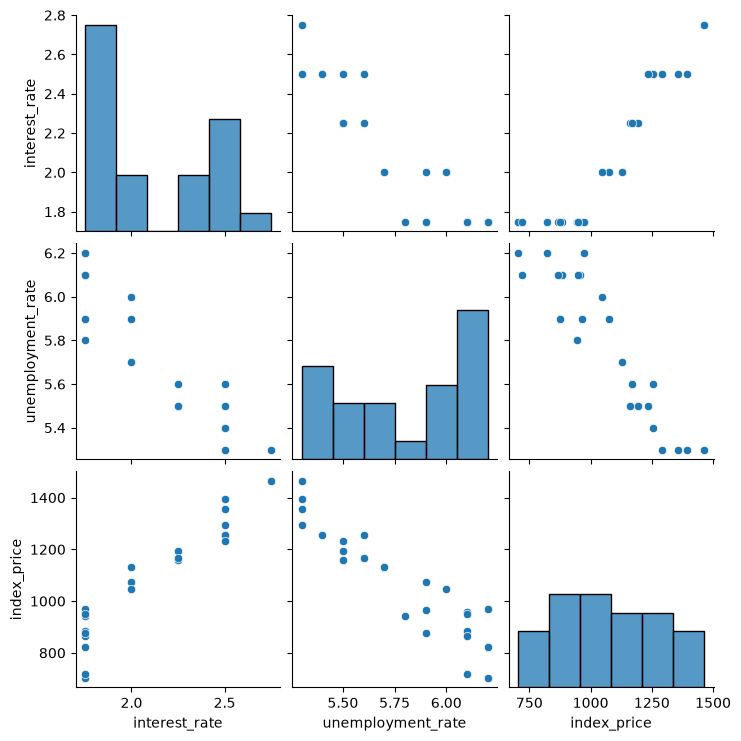

In [9]:
# visualizing the data 

import seaborn as sns

sns.pairplot(df)

Text(0.5, 1.0, 'interest_rate vs unemployment_rate')

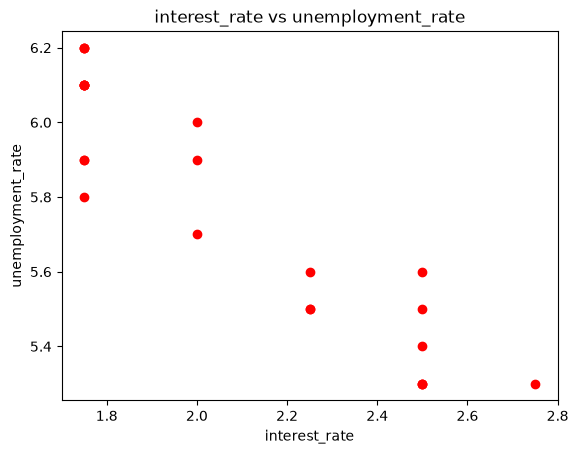

In [10]:
# visualizing the data with matplotlib scatter plot

plt.scatter(df["interest_rate"], df["unemployment_rate"], color = 'r', label = 'interest_rate vs unemployment_rate')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.title('interest_rate vs unemployment_rate')

In [12]:
# devide the features into dependent and independent 

x = df.iloc[:,:-1]
y = df.iloc[:,-1]


In [13]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [14]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [16]:
# regplot form seaborn to visualize the relationship

import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

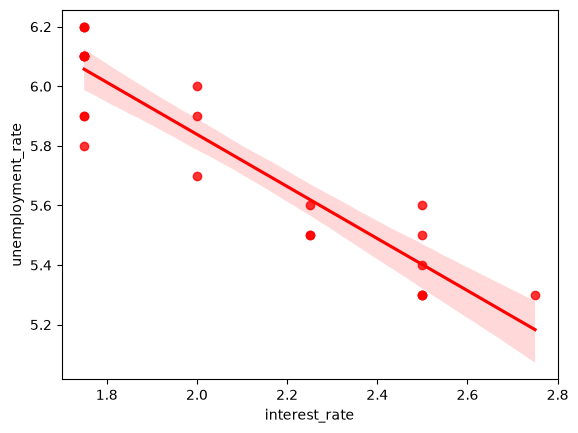

In [17]:
sns.regplot(x = 'interest_rate', y = 'unemployment_rate', data = df, color = 'r')

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

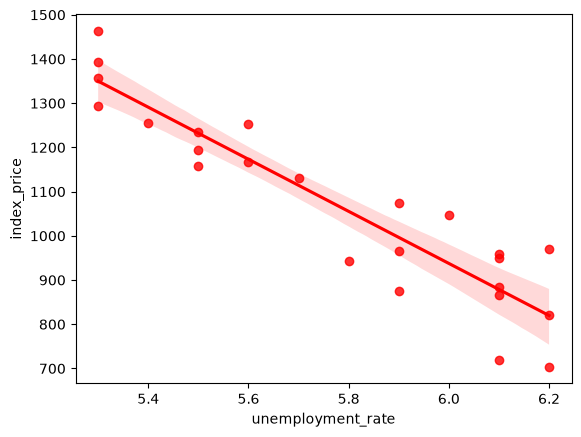

In [18]:
sns.regplot(x = 'unemployment_rate', y = 'index_price', data = df, color = 'r')

<Axes: xlabel='interest_rate', ylabel='index_price'>

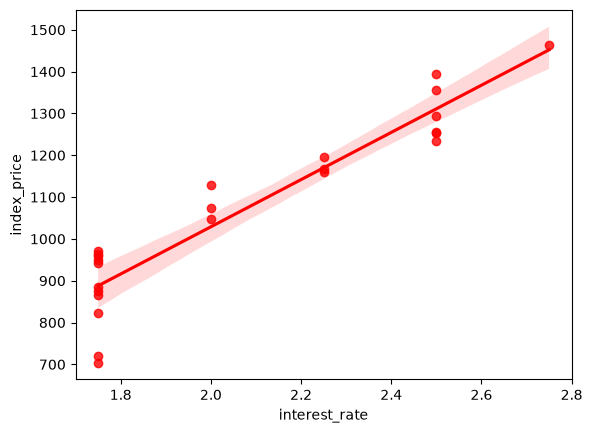

In [19]:
sns.regplot(x = 'interest_rate', y = 'index_price', data = df, color = 'r')

In [20]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [11]:
# train test split

from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [21]:
# standardize the data with sclaer 

from sklearn.preprocessing import StandardScaler

In [22]:
sclaer = StandardScaler()

x_train = sclaer.fit_transform(x_train)
x_test = sclaer.fit_transform(x_test)


In [23]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [24]:
# intialize the model and train it with training data 

from sklearn.linear_model import LinearRegression 


In [25]:
regression_model = LinearRegression()

In [26]:
regression_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


In [27]:
# cross validation to check the accuracy of the model with cross_val_score

from sklearn.model_selection import cross_val_score

In [29]:
validation_score = cross_val_score(regression_model, x_train, y_train, scoring = 'neg_mean_squared_error', cv = 3)

In [30]:
np.mean(validation_score)

np.float64(-5914.828180162386)

In [31]:
# prediction 

y_pred = regression_model.predict(x_test)

In [32]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [33]:
# performance metrics 

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [34]:
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 8108.567426306604
Mean Absolute Error: 73.80444932337097
R2 Score: 0.7591371539010257


In [35]:
# adjusted r2 score 

print("Adjusted R2 Score:", 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

Adjusted R2 Score: 0.5985619231683761


## Assumptions

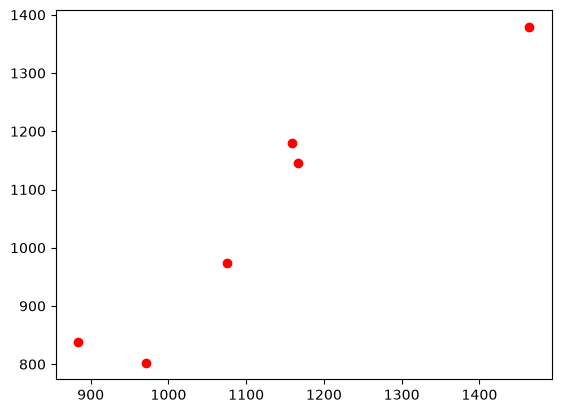

In [36]:
plt.scatter(y_test, y_pred, color = 'r', label = 'y_test vs y_pred')

In [37]:
# residual plot to check the residuals
residuals = y_test - y_pred

print("Residuals:", residuals)

Residuals: 8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


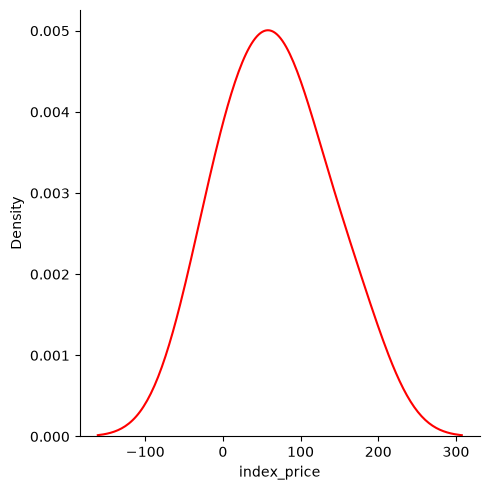

In [38]:
sns.displot(residuals, kind = 'kde', color = 'r')

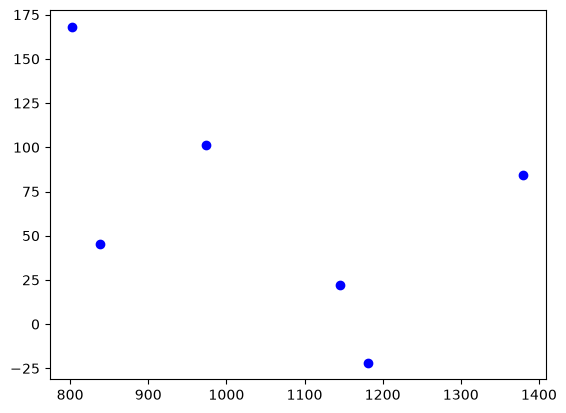

In [40]:
 # scatter plot with prediton and residuals 

plt.scatter(y_pred, residuals, color = 'blue')

In [41]:
# train mode with OLS method 

from statsmodels.api import OLS, add_constant

In [ ]:
ols_model 